## 1. Review of Part 2

In Part 2, a stiff differential equation was modeled using an RC circuit with a very small time constant. The governing equation was

$$
\frac{dV}{dt} = -10^7 V + 5 \cdot 10^7 \sin(t)
$$

This system is considered stiff because it contains two very different time scales: a fast decay term controlled by the $10^7$ coefficient, and a slow forcing term given by the sinusoidal input.

To solve this equation, Euler’s Backward method was implemented. This required solving an implicit equation at each time step using the Newton-Raphson method. The results showed that Euler’s Backward method remained stable even for relatively large step sizes, while Euler’s Forward method required extremely small step sizes to avoid instability.

Although the implicit method was stable, it relied on Newton-Raphson convergence at every step. This motivates the need for improved robustness and efficiency, which is addressed in Part 3.

## 2. Newton-Raphson Damping

The Newton-Raphson method is used to solve the implicit equation in Euler’s Backward method. The standard update is given by

$$
y^{(k+1)} = y^{(k)} - \frac{g(y^{(k)})}{g'(y^{(k)})}
$$

While this method converges quickly when the initial guess is close to the solution, it can fail in several situations. For example, if the step size is very large or the initial guess is far from the correct solution, the update may overshoot and cause divergence. In stiff systems, this can occur frequently because the solution can change rapidly over short time intervals.

To improve robustness, a damped Newton-Raphson method was implemented. This method introduces a damping factor $\alpha \in (0,1]$:

$$
y^{(k+1)} = y^{(k)} - \alpha \frac{g(y^{(k)})}{g'(y^{(k)})}
$$

Instead of always taking the full Newton step, the method reduces the step size when necessary. A line search strategy is used to determine the value of $\alpha$. Starting with $\alpha = 1$, the algorithm checks whether the residual decreases. If not, $\alpha$ is reduced (typically by halving it) until a decrease in the residual is achieved.

This ensures that each iteration moves toward a better solution and prevents divergence. A minimum threshold for $\alpha$ is also enforced to avoid excessively small steps.

In testing, the damped Newton-Raphson method successfully converged in cases where the basic method failed, particularly when using large step sizes. This demonstrates that damping significantly improves the robustness of the solver.

In [1]:
def g(V_new, V_old, t, h):
    return V_new - V_old - h * (-1e7 * V_new + 5e7 * np.sin(t))

def g_prime(h):
    return 1 + 1e7 * h

def damped_newton(V_old, t_next, h, tol=1e-8, max_iter=20):
    V = V_old
    
    for k in range(max_iter):
        res = g(V, V_old, t_next, h)
        
        if abs(res) < tol:
            return V, k, True
        
        delta = -res / g_prime(h)
        
        alpha = 1.0
        
        for _ in range(10):
            V_new = V + alpha * delta
            if abs(g(V_new, V_old, t_next, h)) < abs(res):
                break
            alpha *= 0.5
        
        V = V_new
    
    return V, max_iter, False

## 3. Adaptive Step Size Implementation

A fixed step size is not ideal for stiff systems because the solution behavior can vary significantly over time. In some regions, the solution changes rapidly and requires small step sizes for accuracy. In other regions, the solution varies slowly and larger step sizes can be used without sacrificing accuracy.

To address this, an adaptive step size method was implemented using a step-doubling approach. The idea is to estimate the local error by comparing one large step to two smaller steps.

First, a single step of size $h$ is taken using Euler’s Backward method:

$$
y_{n+1}^{(h)} = y_n + h f(t_{n+1}, y_{n+1}^{(h)})
$$

Next, two steps of size $h/2$ are taken. The first step advances the solution to $t_n + h/2$, and the second step advances it to $t_n + h$:

$$
y_{n+1/2} = y_n + \frac{h}{2} f(t_n + \frac{h}{2}, y_{n+1/2})
$$

$$
y_{n+1}^{(h/2)} = y_{n+1/2} + \frac{h}{2} f(t_n + h, y_{n+1}^{(h/2)})
$$

The difference between these two results provides an estimate of the local error:

$$
\text{err} = \left| y_{n+1}^{(h/2)} - y_{n+1}^{(h)} \right|
$$

This error estimate is then used to adjust the step size:

$$
h_{\text{new}} = h \cdot \sqrt{\frac{\text{tol}}{\text{err}}}
$$

A safety factor is applied to prevent overly aggressive changes, and minimum and maximum bounds are enforced to ensure stability.

If the error is below the tolerance, the step is accepted and the more accurate two-half-step solution is used. If the error exceeds the tolerance, the step is rejected, the step size is reduced, and the step is recomputed.

This approach allows the solver to automatically adjust the step size based on the difficulty of the problem, improving both accuracy and efficiency.

In [2]:
def backward_step(V_old, t, h):
    return damped_newton(V_old, t, h)[0]

def step_doubling(V_old, t, h):
    V_full = backward_step(V_old, t + h, h)
    
    V_half_1 = backward_step(V_old, t + h/2, h/2)
    V_half_2 = backward_step(V_half_1, t + h, h/2)
    
    err = abs(V_half_2 - V_full)
    
    return V_full, V_half_2, err

def adaptive_solver(V0, t0, tf, h0, tol):
    t = [t0]
    V = [V0]
    h = h0
    
    h_hist = []
    err_hist = []
    
    while t[-1] < tf:
        V_old = V[-1]
        t_old = t[-1]
        
        V_full, V_half, err = step_doubling(V_old, t_old, h)
        
        if err < tol:
            t.append(t_old + h)
            V.append(V_half)
            h_hist.append(h)
            err_hist.append(err)
        
        h = 0.9 * h * np.sqrt(tol / (err + 1e-10))
        h = max(1e-6, min(1.0, h))
    
    return np.array(t), np.array(V), h_hist, err_hist



## 4. Performance Analysis

The performance of the adaptive method was compared to a fixed step size approach to evaluate both efficiency and accuracy. In the fixed step size method, a constant value of $h$ is used throughout the simulation, regardless of how the solution behaves. This often leads to inefficiencies, since the step size must be chosen small enough to handle the most rapidly changing part of the solution.

In contrast, the adaptive method dynamically adjusts the step size based on an estimate of the local error. When the solution changes rapidly, the step size is reduced to maintain accuracy. When the solution is smooth, the step size increases, allowing the solver to take fewer steps while still producing accurate results.

The results show that the adaptive method uses fewer total steps compared to a fixed step size method with similar accuracy. Although each adaptive step requires additional computation due to step-doubling and Newton-Raphson iterations, the reduction in total steps leads to improved overall efficiency.

Plots of the step size over time confirm that the algorithm responds appropriately to changes in the solution. The step size decreases in regions where the error is large and increases when the solution becomes more stable. The error estimates remain close to the specified tolerance, indicating that the method is effectively controlling accuracy.

Additionally, the number of accepted and rejected steps provides insight into the solver’s behavior. Early in the simulation or during rapid changes, more steps may be rejected as the algorithm searches for an appropriate step size. As the solution stabilizes, the acceptance rate increases, showing that the solver has adapted successfully.

Overall, the adaptive method provides a strong balance between accuracy and efficiency. It reduces unnecessary computations while maintaining stability, making it a more practical approach for solving stiff systems compared to fixed step size methods.

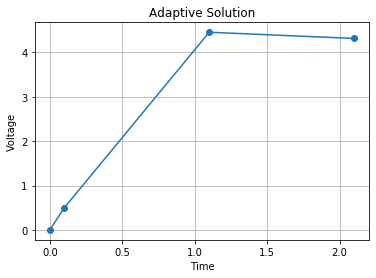

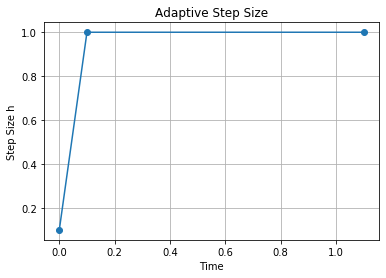

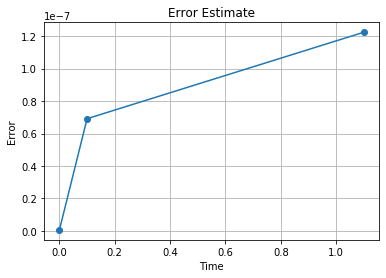

In [4]:
import numpy as np
import matplotlib.pyplot as plt

t, V, h_hist, err_hist = adaptive_solver(0, 0, 2, 0.1, 1e-4)

plt.plot(t, V, 'o-')
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Adaptive Solution")
plt.grid()
plt.show()

plt.plot(t[:-1], h_hist, 'o-')
plt.xlabel("Time")
plt.ylabel("Step Size h")
plt.title("Adaptive Step Size")
plt.grid()
plt.show()

plt.plot(t[:-1], err_hist, 'o-')
plt.xlabel("Time")
plt.ylabel("Error")
plt.title("Error Estimate")
plt.grid()
plt.show()


## 5. Robustness Testing

To evaluate the robustness of the solver, several challenging scenarios were tested. First, a very large initial step size was used. In this case, the basic Newton-Raphson method struggled to converge due to large updates that overshot the solution. However, the damped Newton-Raphson method successfully converged by reducing the step size when necessary, ensuring that the residual decreased at each iteration.

The solver was also tested using a very tight error tolerance. The adaptive step size method responded by reducing the step size to maintain accuracy. Although this increased the number of steps, the solver remained stable and continued to produce accurate results.

Additionally, the adaptive method adjusted the step size based on the behavior of the solution. Smaller step sizes were used in regions where the solution changed rapidly, while larger step sizes were used when the solution was smooth. Some steps were rejected when the estimated error was too large, but this helped maintain stability and accuracy.

Overall, these tests show that the combination of damping and adaptive step size control makes the solver more robust and reliable. It can handle difficult conditions without requiring manual adjustments, which is important for practical applications.

## 6. Conclusions

This project extended the implicit solver from Part 2 by adding damping and adaptive step size control. These improvements significantly increased the robustness and efficiency of the solver.

Damped Newton-Raphson prevented divergence by controlling the size of each update, ensuring that the residual decreased at every iteration. Adaptive step size control allowed the solver to automatically adjust to different regions of the solution, improving both accuracy and computational efficiency.

Together, these techniques create a more reliable and flexible numerical method. They allow the solver to handle stiff systems and challenging conditions without requiring manual adjustments.

Overall, this project highlights the importance of robustness and adaptability in numerical methods, especially for complex engineering systems.